<a href="https://colab.research.google.com/github/nihemelandu/clickstream-purchase-intent/blob/main/notebooks/01_data_understanding.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd

In [1]:
# Cell 1 — Mount Google Drive and verify file access

from google.colab import drive
drive.mount('/content/drive')

import os

# Define file paths
BASE_PATH = '/content/drive/My Drive/'
FILES = {
    'oct': os.path.join(BASE_PATH, '2019-Oct.csv'),
    'nov': os.path.join(BASE_PATH, '2019-Nov.csv')
}

# Verify files exist and check sizes
for name, path in FILES.items():
    if os.path.exists(path):
        size_gb = os.path.getsize(path) / (1024 ** 3)
        print(f"{name}: {path}")
        print(f"  Size: {size_gb:.2f} GB")
        print(f"  Exists: True\n")
    else:
        print(f"{name}: FILE NOT FOUND at {path}\n")

Mounted at /content/drive
oct: /content/drive/My Drive/2019-Oct.csv
  Size: 5.28 GB
  Exists: True

nov: /content/drive/My Drive/2019-Nov.csv
  Size: 8.39 GB
  Exists: True



In [2]:
# Cell 2 — Install DuckDB and import libraries

!pip install duckdb -q

import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Connect to DuckDB — in-memory analytical database
con = duckdb.connect()

# Verify DuckDB version
print(f"DuckDB version: {duckdb.__version__}")
print(f"Pandas version: {pd.__version__}")
print("All libraries imported successfully")

DuckDB version: 1.3.2
Pandas version: 2.2.2
All libraries imported successfully


In [3]:
# Cell 3 — Initial data inspection

# Inspect schema and first few rows of October file
print("=" * 60)
print("OCTOBER 2019 — SCHEMA AND SAMPLE ROWS")
print("=" * 60)

oct_sample = con.execute("""
    SELECT *
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Oct.csv',
        sample_size = 10000
    )
    LIMIT 5
""").df()

print(oct_sample.to_string())
print(f"\nColumn names: {list(oct_sample.columns)}")
print(f"Data types:\n{oct_sample.dtypes}")

# Inspect schema and first few rows of November file
print("\n" + "=" * 60)
print("NOVEMBER 2019 — SCHEMA AND SAMPLE ROWS")
print("=" * 60)

nov_sample = con.execute("""
    SELECT *
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Nov.csv',
        sample_size = 10000
    )
    LIMIT 5
""").df()

print(nov_sample.to_string())
print(f"\nColumn names: {list(nov_sample.columns)}")
print(f"Data types:\n{nov_sample.dtypes}")

# Confirm schemas match between the two files
oct_cols = list(oct_sample.columns)
nov_cols = list(nov_sample.columns)

print("\n" + "=" * 60)
print("SCHEMA CONSISTENCY CHECK")
print("=" * 60)
if oct_cols == nov_cols:
    print("✓ Both files have identical column names and order")
else:
    print("⚠ Column mismatch between files")
    print(f"  October columns:  {oct_cols}")
    print(f"  November columns: {nov_cols}")

OCTOBER 2019 — SCHEMA AND SAMPLE ROWS
           event_time event_type  product_id          category_id                        category_code     brand     price    user_id                          user_session
0 2019-10-01 00:00:00       view    44600062  2103807459595387724                                 None  shiseido   35.7900  541312140  72d76fde-8bb3-4e00-8c23-a032dfed738c
1 2019-10-01 00:00:00       view     3900821  2053013552326770905  appliances.environment.water_heater      aqua   33.2000  554748717  9333dfbd-b87a-4708-9857-6336556b0fcc
2 2019-10-01 00:00:01       view    17200506  2053013559792632471           furniture.living_room.sofa      None  543.1000  519107250  566511c2-e2e3-422b-b695-cf8e6e792ca8
3 2019-10-01 00:00:01       view     1307067  2053013558920217191                   computers.notebook    lenovo  251.7400  550050854  7c90fc70-0e80-4590-96f3-13c02c18c713
4 2019-10-01 00:00:04       view     1004237  2053013555631882655               electronics.smartphone

ROW COUNTS PER FILE


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

October 2019:       42,448,764 rows
November 2019:      67,501,979 rows
Combined:          109,950,743 rows

November is 1.59x larger than October

EVENT TYPE DISTRIBUTION — OCTOBER


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type    count  percentage
      view 40779399     96.0700
      cart   926516      2.1800
  purchase   742849      1.7500

EVENT TYPE DISTRIBUTION — NOVEMBER


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type    count  percentage
      view 63556110     94.1500
      cart  3028930      4.4900
  purchase   916939      1.3600

EVENT TYPE DISTRIBUTION — COMBINED


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

event_type     count  percentage
      view 104335509     94.8900
      cart   3955446      3.6000
  purchase   1659788      1.5100


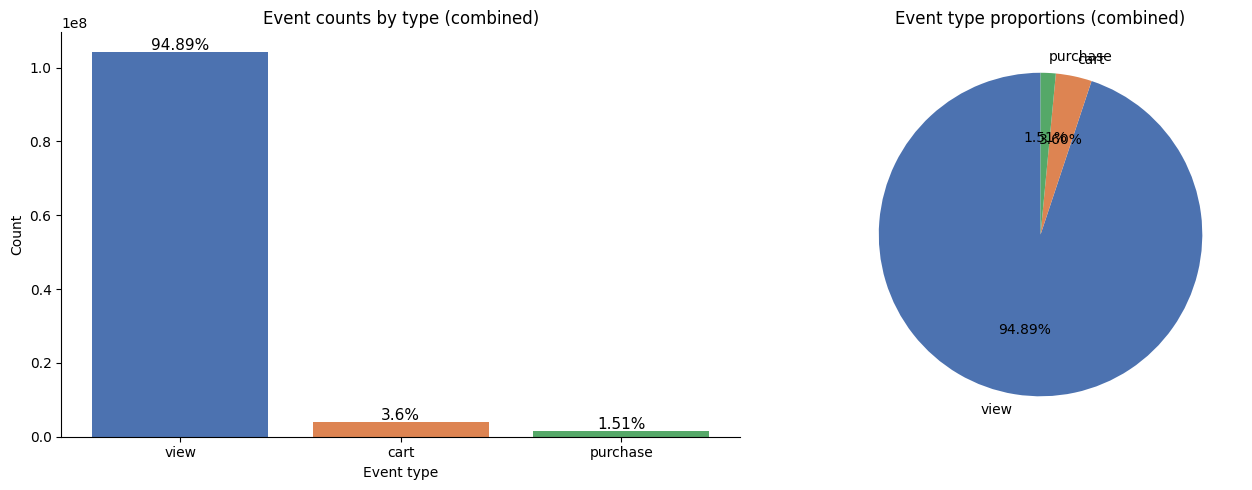


Chart saved as event_distribution.png


In [4]:
# Cell 4 — Row counts and combined volume

print("=" * 60)
print("ROW COUNTS PER FILE")
print("=" * 60)

oct_count = con.execute("""
    SELECT COUNT(*) as row_count
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Oct.csv',
        sample_size = -1
    )
""").df()

nov_count = con.execute("""
    SELECT COUNT(*) as row_count
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Nov.csv',
        sample_size = -1
    )
""").df()

oct_rows = oct_count['row_count'].values[0]
nov_rows = nov_count['row_count'].values[0]
total_rows = oct_rows + nov_rows

print(f"October 2019:  {oct_rows:>15,.0f} rows")
print(f"November 2019: {nov_rows:>15,.0f} rows")
print(f"Combined:      {total_rows:>15,.0f} rows")
print(f"\nNovember is {(nov_rows / oct_rows):.2f}x larger than October")

print("\n" + "=" * 60)
print("EVENT TYPE DISTRIBUTION — OCTOBER")
print("=" * 60)

oct_events = con.execute("""
    SELECT
        event_type,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Oct.csv',
        sample_size = -1
    )
    GROUP BY event_type
    ORDER BY count DESC
""").df()

print(oct_events.to_string(index=False))

print("\n" + "=" * 60)
print("EVENT TYPE DISTRIBUTION — NOVEMBER")
print("=" * 60)

nov_events = con.execute("""
    SELECT
        event_type,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Nov.csv',
        sample_size = -1
    )
    GROUP BY event_type
    ORDER BY count DESC
""").df()

print(nov_events.to_string(index=False))

print("\n" + "=" * 60)
print("EVENT TYPE DISTRIBUTION — COMBINED")
print("=" * 60)

combined_events = con.execute("""
    SELECT
        event_type,
        COUNT(*) as count,
        ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 2) as percentage
    FROM (
        SELECT event_type FROM read_csv_auto(
            '/content/drive/My Drive/2019-Oct.csv',
            sample_size = -1
        )
        UNION ALL
        SELECT event_type FROM read_csv_auto(
            '/content/drive/My Drive/2019-Nov.csv',
            sample_size = -1
        )
    )
    GROUP BY event_type
    ORDER BY count DESC
""").df()

print(combined_events.to_string(index=False))

# Visualise combined event distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#4C72B0', '#DD8452', '#55A868']

# Bar chart
axes[0].bar(
    combined_events['event_type'],
    combined_events['count'],
    color=colors
)
axes[0].set_title('Event counts by type (combined)')
axes[0].set_xlabel('Event type')
axes[0].set_ylabel('Count')
for i, (count, pct) in enumerate(
    zip(combined_events['count'], combined_events['percentage'])
):
    axes[0].text(
        i, count + total_rows * 0.005,
        f'{pct}%',
        ha='center', fontsize=11
    )

# Pie chart
axes[1].pie(
    combined_events['count'],
    labels=combined_events['event_type'],
    autopct='%1.2f%%',
    colors=colors,
    startangle=90
)
axes[1].set_title('Event type proportions (combined)')

plt.tight_layout()
plt.savefig('event_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as event_distribution.png")

MISSING VALUE ANALYSIS — OCTOBER


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

            feature         count  percentage
   event_time_nulls        0.0000      0.0000
   event_type_nulls        0.0000      0.0000
   product_id_nulls        0.0000      0.0000
  category_id_nulls        0.0000      0.0000
category_code_nulls 13515609.0000     31.8400
        brand_nulls  6113008.0000     14.4000
        price_nulls        0.0000      0.0000
      user_id_nulls        0.0000      0.0000
 user_session_nulls        2.0000      0.0000

MISSING VALUE ANALYSIS — NOVEMBER


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

            feature         count  percentage
   event_time_nulls        0.0000      0.0000
   event_type_nulls        0.0000      0.0000
   product_id_nulls        0.0000      0.0000
  category_id_nulls        0.0000      0.0000
category_code_nulls 21898171.0000     32.4400
        brand_nulls  9218235.0000     13.6600
        price_nulls        0.0000      0.0000
      user_id_nulls        0.0000      0.0000
 user_session_nulls       10.0000      0.0000

MISSING VALUE SUMMARY — COMBINED
            feature         count  percentage
   event_time_nulls        0.0000      0.0000
   event_type_nulls        0.0000      0.0000
   product_id_nulls        0.0000      0.0000
  category_id_nulls        0.0000      0.0000
category_code_nulls 35413780.0000     32.2100
        brand_nulls 15331243.0000     13.9400
        price_nulls        0.0000      0.0000
      user_id_nulls        0.0000      0.0000
 user_session_nulls       12.0000      0.0000


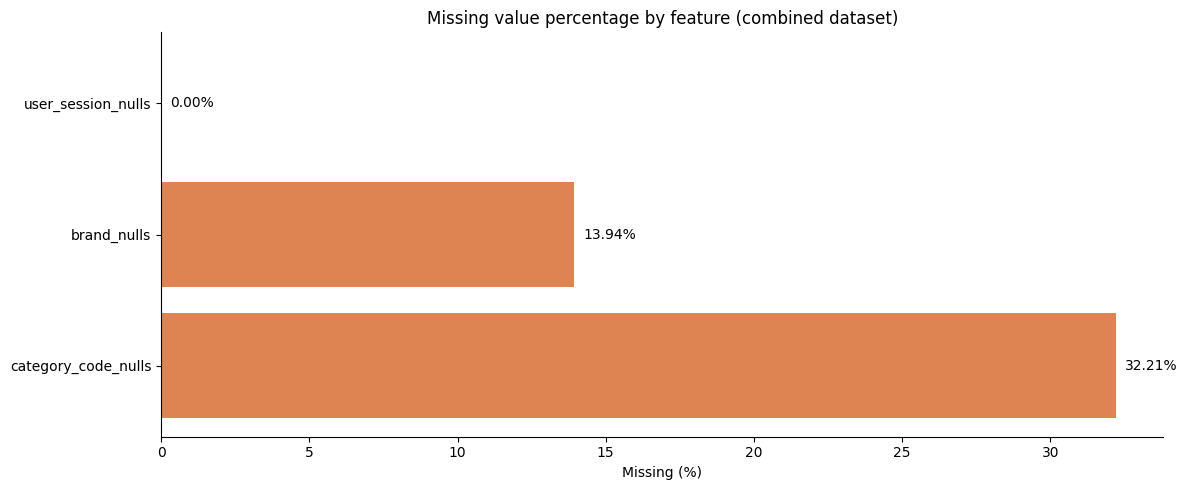


Chart saved as missing_values.png


In [5]:
# Cell 5 — Missing value analysis

print("=" * 60)
print("MISSING VALUE ANALYSIS — OCTOBER")
print("=" * 60)

oct_missing = con.execute("""
    SELECT
        COUNT(*) as total_rows,
        SUM(CASE WHEN event_time IS NULL THEN 1 ELSE 0 END) as event_time_nulls,
        SUM(CASE WHEN event_type IS NULL THEN 1 ELSE 0 END) as event_type_nulls,
        SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) as product_id_nulls,
        SUM(CASE WHEN category_id IS NULL THEN 1 ELSE 0 END) as category_id_nulls,
        SUM(CASE WHEN category_code IS NULL THEN 1 ELSE 0 END) as category_code_nulls,
        SUM(CASE WHEN brand IS NULL THEN 1 ELSE 0 END) as brand_nulls,
        SUM(CASE WHEN price IS NULL THEN 1 ELSE 0 END) as price_nulls,
        SUM(CASE WHEN user_id IS NULL THEN 1 ELSE 0 END) as user_id_nulls,
        SUM(CASE WHEN user_session IS NULL THEN 1 ELSE 0 END) as user_session_nulls
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Oct.csv',
        sample_size = -1
    )
""").df()

# Reshape for readability
oct_missing_t = oct_missing.T.reset_index()
oct_missing_t.columns = ['feature', 'count']
oct_missing_t['percentage'] = (
    oct_missing_t['count'] / oct_rows * 100
).round(2)
oct_missing_t = oct_missing_t[oct_missing_t['feature'] != 'total_rows']

print(oct_missing_t.to_string(index=False))

print("\n" + "=" * 60)
print("MISSING VALUE ANALYSIS — NOVEMBER")
print("=" * 60)

nov_missing = con.execute("""
    SELECT
        COUNT(*) as total_rows,
        SUM(CASE WHEN event_time IS NULL THEN 1 ELSE 0 END) as event_time_nulls,
        SUM(CASE WHEN event_type IS NULL THEN 1 ELSE 0 END) as event_type_nulls,
        SUM(CASE WHEN product_id IS NULL THEN 1 ELSE 0 END) as product_id_nulls,
        SUM(CASE WHEN category_id IS NULL THEN 1 ELSE 0 END) as category_id_nulls,
        SUM(CASE WHEN category_code IS NULL THEN 1 ELSE 0 END) as category_code_nulls,
        SUM(CASE WHEN brand IS NULL THEN 1 ELSE 0 END) as brand_nulls,
        SUM(CASE WHEN price IS NULL THEN 1 ELSE 0 END) as price_nulls,
        SUM(CASE WHEN user_id IS NULL THEN 1 ELSE 0 END) as user_id_nulls,
        SUM(CASE WHEN user_session IS NULL THEN 1 ELSE 0 END) as user_session_nulls
    FROM read_csv_auto(
        '/content/drive/My Drive/2019-Nov.csv',
        sample_size = -1
    )
""").df()

nov_missing_t = nov_missing.T.reset_index()
nov_missing_t.columns = ['feature', 'count']
nov_missing_t['percentage'] = (
    nov_missing_t['count'] / nov_rows * 100
).round(2)
nov_missing_t = nov_missing_t[nov_missing_t['feature'] != 'total_rows']

print(nov_missing_t.to_string(index=False))

print("\n" + "=" * 60)
print("MISSING VALUE SUMMARY — COMBINED")
print("=" * 60)

combined_missing = oct_missing_t.copy()
combined_missing['count'] = oct_missing_t['count'] + nov_missing_t['count']
combined_missing['percentage'] = (
    combined_missing['count'] / total_rows * 100
).round(2)

print(combined_missing.to_string(index=False))

# Visualise missing values
fig, ax = plt.subplots(figsize=(12, 5))

features_with_missing = combined_missing[combined_missing['count'] > 0]

bars = ax.barh(
    features_with_missing['feature'],
    features_with_missing['percentage'],
    color=['#DD8452' if p > 10 else '#4C72B0'
           for p in features_with_missing['percentage']]
)

ax.set_xlabel('Missing (%)')
ax.set_title('Missing value percentage by feature (combined dataset)')

for bar, pct in zip(
    bars,
    features_with_missing['percentage']
):
    ax.text(
        bar.get_width() + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.2f}%',
        va='center'
    )

plt.tight_layout()
plt.savefig('missing_values.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nChart saved as missing_values.png")